[CKPT] /Users/adi/Desktop/c015_b03_jump_plateau_2026-02-02_21-44-22_for_play.pth
[PREV_CKPT] /Users/adi/Desktop/Freeze_att71/Adapt_Freeze71__run00__c015_jump__self__to_walk__seed42/models_copied/c001_b01_walk_plateau_2026-04-03_22-53-40_for_play.pth
[STATES] /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/StatesConcat/ALL_states_concat.npy | N=400000


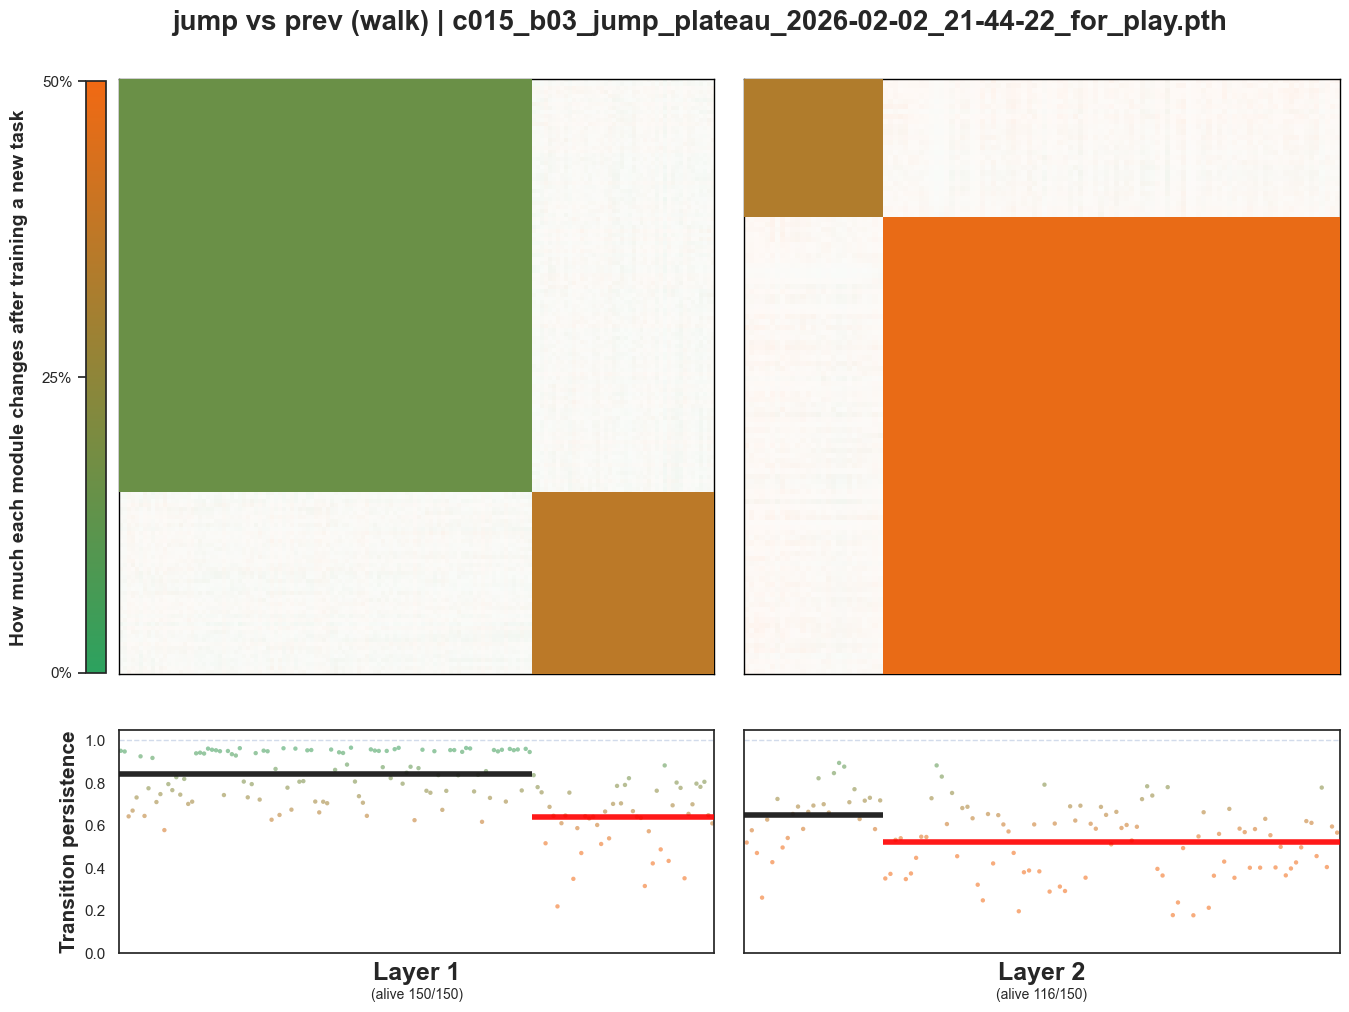

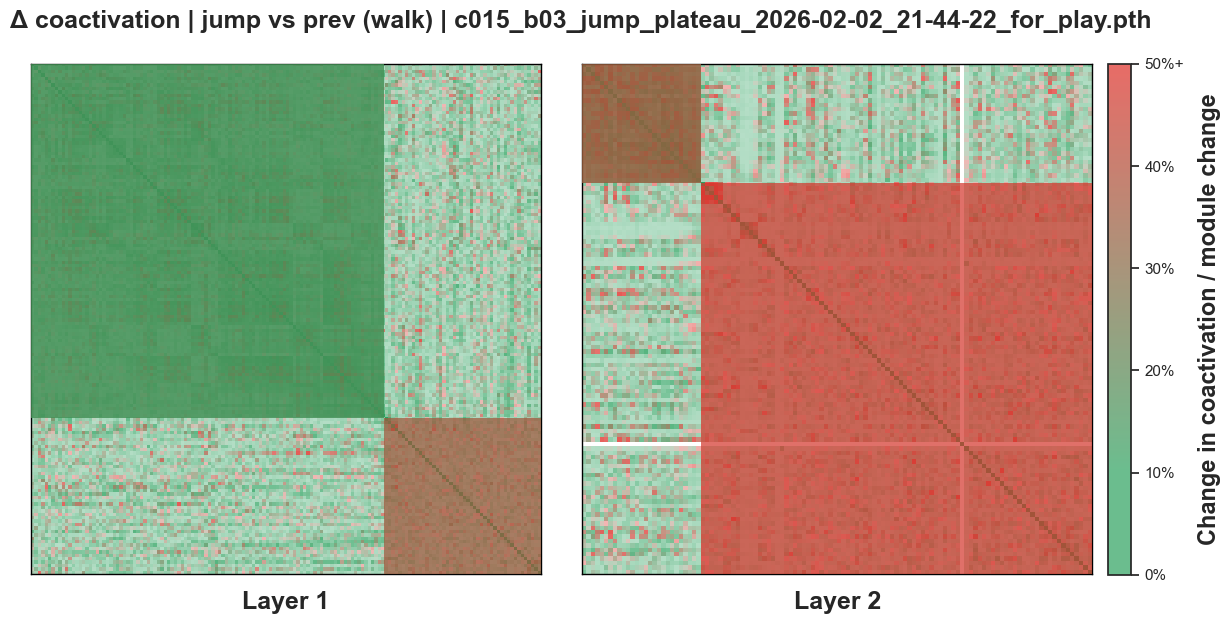

In [1]:
from __future__ import annotations

import os
import re
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Rectangle
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize

# ============================================================
# === TWO-CHECKPOINT ONE-SIDED TRANSITION ANALYSIS (NOTEBOOK)
# === - Compare exactly 2 paths: CKPT vs PREV_CKPT
# === - Show the plot inline (no saving to disk)
# === - ALSO: plot Δ coactivation heatmaps (2 layers)
# ============================================================

# -------------------------
# USER KNOBS (EDIT THESE)
# -------------------------
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

MODELS_DIR = (
    REPO_ROOT
    / "Checkpoints_States_selectedGraphs"
    / "WalkSpinJump_relu"
    / "WSJ_relu_7_2026-01-30_23-29-24/models"
).resolve()

# Set these to the two checkpoint files you want to compare
CKPT = str("/Users/adi/Desktop/c015_b03_jump_plateau_2026-02-02_21-44-22_for_play.pth")
PREV_CKPT = str("/Users/adi/Desktop/Freeze_att71/Adapt_Freeze71__run00__c015_jump__self__to_walk__seed42/models_copied/c001_b01_walk_plateau_2026-04-03_22-53-40_for_play.pth")

# Global state pool (same as before)
ALL_STATES_PATH = str(
    (REPO_ROOT / "Checkpoints_States_selectedGraphs" / "StatesConcat" / "ALL_states_concat.npy").resolve()
)
N_ALL_STATES = 400_000

# Analysis knobs (kept intact)
LAYER_INDICES = [0, 1]
SEED = 42
EPS = 1e-8
MIN_STD = 1e-5
ACTIVATION = "relu"   # {"elu","relu","tanh"}
TAU = 0.70
BD_MIN_BLOCK_SIZE = 1

# NEW: Δ coactivation plot knobs
SHOW_BLOCK_OVERLAYS_ON_DELTA = True
DELTA_BG_ALPHA = 1
DELTA_CBAR_LABEL = "Change in coactivation / module change"
DELTA_VMAX = 1.0  # raw Δ|cos| still capped at 1.0 internally

sns.set_theme(style="white", font="Arial")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]

def _seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

_seed_everything(SEED)

def _basename(p: str) -> str:
    return os.path.basename(str(p))

def _infer_behavior_from_path(p: str) -> str:
    s = _basename(p).lower()
    if re.search(r"(^|[^a-z])walk([^a-z]|$)", s) or "_walk_" in s:
        return "walk"
    if re.search(r"(^|[^a-z])(spin|wiggle)([^a-z]|$)", s) or "_spin_" in s or "_wiggle_" in s:
        return "spin"
    if re.search(r"(^|[^a-z])(jump|bob)([^a-z]|$)", s) or "_jump_" in s or "_bob_" in s:
        return "jump"
    return "unknown"

def _torch_load_compat(path: str):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")

def _load_rlg_forplay_state_dict(path: str) -> dict:
    payload = _torch_load_compat(path)
    if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
        sd = {}
        for k, v in payload["model"].items():
            sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
        return sd
    raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")

def _discover_actor_mlp_layers(state_dict: dict):
    candidates = []
    for k in state_dict.keys():
        if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
            parts = k.split(".")
            try:
                idx = int(parts[-2])
                bias_key = k[:-6] + "bias"
                if bias_key in state_dict:
                    candidates.append((idx, k, bias_key))
            except Exception:
                candidates.append((10**6, k, k[:-6] + "bias"))
    candidates.sort(key=lambda t: (t[0], t[1]))
    return candidates

def _first_linear_in(actor_layers, sd):
    if not actor_layers:
        raise RuntimeError("No actor MLP layers found.")
    _, wkey, _ = actor_layers[0]
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    if W.ndim != 2:
        raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
    return W.shape[1], W.shape[0]

def _activation(x: np.ndarray, name: str) -> np.ndarray:
    if name == "elu":
        y = x.copy()
        neg = x <= 0
        y[neg] = np.expm1(x[neg])
        return y
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "tanh":
        return np.tanh(x)
    raise ValueError(f"Unsupported ACTIVATION '{name}'")

def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name, max_layers: int):
    outs = []
    h = X
    L = min(max_layers, len(actor_layers))
    for li in range(L):
        _, wkey, bkey = actor_layers[li]
        W = sd[wkey]
        b = sd[bkey]
        if isinstance(W, torch.Tensor):
            W = W.detach().cpu().numpy()
        if isinstance(b, torch.Tensor):
            b = b.detach().cpu().numpy()
        h = h @ W.T + b[None, :]
        h = _activation(h, activation_name)
        outs.append(h.astype(np.float32, copy=False))
    return outs

def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
    X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
    outs = _actor_hidden_forward_numpy(
        X, actor_layers, sd, activation_name, max_layers=max(LAYER_INDICES) + 1
    )
    if layer_idx < 0 or layer_idx >= len(outs):
        raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
    return outs[layer_idx]

def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)

def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    dead_idx = np.where(dead_mask)[0].astype(int)
    alive_idx = np.where(~dead_mask)[0].astype(int)
    return dead_idx, alive_idx

def cosine_sim_matrix_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError("cosine_sim_matrix_cols expects 2D array (T, N)")
    n = X.shape[1]
    if n == 0:
        return np.zeros((0, 0), np.float32)
    if n == 1:
        return np.ones((1, 1), np.float32)

    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn = X / norms
    R = (Xn.T @ Xn).astype(np.float32, copy=False)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R

def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros(
            (A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0),
            dtype=np.float32
        )
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

    nA = np.linalg.norm(A, axis=0, keepdims=True)
    nB = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0

    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)

    i_idx, j_idx = linear_sum_assignment(-sim)
    matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals

def _safe_cos_abs(a, b, eps: float = 1e-8) -> float:
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0:
        return 0.0
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c):
        return 0.0
    c = max(-1.0, min(1.0, c))
    return float(abs(c))

def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)
    sorted_cids = unique_cids[order]
    cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)

def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return np.arange(0, dtype=int)
    if base_order is None:
        base_order = np.arange(n, dtype=int)
    base_order = np.asarray(base_order)

    unique_cids = np.unique(labels)
    sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]

    labels_in_base = labels[base_order]
    new_order_list = []
    for cid in sorted_cids:
        new_order_list.append(base_order[labels_in_base == cid])
    return np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)

def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:
        return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep = [c for c in np.unique(comp) if c != -1]
            remap = {c: i for i, c in enumerate(keep)}
            comp2 = np.empty(n, dtype=int)
            for i in range(n):
                c = comp[i]
                comp2[i] = remap[c] if c != -1 else len(keep)
            comp = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels

def compute_one_sided_transition_analysis(
    ckpt_path: str,
    prev_ckpt_path: str,
    all_states_path: str,
    n_states: int,
    fixed_state_indices: np.ndarray | None = None,
):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(ckpt_path)
    if not os.path.exists(prev_ckpt_path):
        raise FileNotFoundError(prev_ckpt_path)
    if not os.path.exists(all_states_path):
        raise FileNotFoundError(all_states_path)

    sd_ckpt = _load_rlg_forplay_state_dict(ckpt_path)
    sd_prev_ckpt = _load_rlg_forplay_state_dict(prev_ckpt_path)

    layers_ckpt = _discover_actor_mlp_layers(sd_ckpt)
    layers_prev_ckpt = _discover_actor_mlp_layers(sd_prev_ckpt)
    if not layers_ckpt:
        raise RuntimeError(f"[ckpt] no actor layers found: {ckpt_path}")
    if not layers_prev_ckpt:
        raise RuntimeError(f"[prev_ckpt] no actor layers found: {prev_ckpt_path}")

    obs_ckpt, _ = _first_linear_in(layers_ckpt, sd_ckpt)
    obs_prev_ckpt, _ = _first_linear_in(layers_prev_ckpt, sd_prev_ckpt)
    if obs_ckpt != obs_prev_ckpt:
        raise ValueError(f"obs mismatch: ckpt={obs_ckpt}, prev_ckpt={obs_prev_ckpt}")

    all_states = np.load(all_states_path)
    if all_states.ndim != 2:
        raise ValueError(f"{all_states_path} must be 2D; got {all_states.shape}")
    if all_states.shape[1] != obs_ckpt:
        raise ValueError(f"states obs_dim={all_states.shape[1]}, expected {obs_ckpt}")

    n_avail = all_states.shape[0]
    n_pick = int(n_states)

    if fixed_state_indices is None:
        idx = np.random.choice(n_avail, size=n_pick, replace=(n_avail < n_pick))
    else:
        idx = np.asarray(fixed_state_indices, dtype=int).copy()
        if idx.size != n_pick:
            raise ValueError(f"fixed_state_indices has size {idx.size}, expected {n_pick}")
        if idx.min() < 0 or idx.max() >= n_avail:
            raise ValueError(f"fixed_state_indices out of bounds for n_avail={n_avail}")

    X = all_states[idx].astype(np.float32, copy=False)
    ref_inputs = torch.as_tensor(X, dtype=torch.float32, device="cpu")

    layer_results = []

    for layer_idx in LAYER_INDICES:
        acts_ckpt_full = get_layer_output_batch_from_ckpt(sd_ckpt, ref_inputs, layer_idx, layers_ckpt, ACTIVATION)
        acts_prev_ckpt_full = get_layer_output_batch_from_ckpt(sd_prev_ckpt, ref_inputs, layer_idx, layers_prev_ckpt, ACTIVATION)

        dead_ckpt, alive_ckpt = _dead_alive_indices(acts_ckpt_full, MIN_STD)
        dead_prev_ckpt, alive_prev_ckpt = _dead_alive_indices(acts_prev_ckpt_full, MIN_STD)

        acts_ckpt = acts_ckpt_full[:, alive_ckpt] if alive_ckpt.size else acts_ckpt_full[:, :0]
        acts_prev_ckpt = acts_prev_ckpt_full[:, alive_prev_ckpt] if alive_prev_ckpt.size else acts_prev_ckpt_full[:, :0]

        A_ckpt = _zscore_cols(acts_ckpt, eps=EPS) if acts_ckpt.size else acts_ckpt.astype(np.float32, copy=False)
        A_prev_ckpt = _zscore_cols(acts_prev_ckpt, eps=EPS) if acts_prev_ckpt.size else acts_prev_ckpt.astype(np.float32, copy=False)

        n_ckpt_alive = int(A_ckpt.shape[1])
        n_prev_ckpt_alive = int(A_prev_ckpt.shape[1])

        R_ckpt = cosine_sim_matrix_cols(A_ckpt, eps=EPS)
        R_prev_ckpt = cosine_sim_matrix_cols(A_prev_ckpt, eps=EPS)

        R_ckpt_abs = np.abs(R_ckpt)

        order0, labels0 = blockdiag_rcm_blocks_from_abs(R_ckpt_abs, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE)
        labels_ckpt = _relabel_clusters_by_size(labels0)
        order_ckpt = _order_by_cluster_size(labels_ckpt, base_order=order0)

        _, i_idx, j_idx, _ = hungarian_match_cosine(A_ckpt, A_prev_ckpt, eps=EPS)

        pers_by_ckpt = np.full(n_ckpt_alive, np.nan, dtype=np.float32)

        if i_idx.size:
            i_idx = i_idx.astype(int, copy=False)
            j_idx = j_idx.astype(int, copy=False)

            R_ckpt_sub = R_ckpt[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
            R_prev_ckpt_sub = R_prev_ckpt[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
            np.fill_diagonal(R_ckpt_sub, 0.0)
            np.fill_diagonal(R_prev_ckpt_sub, 0.0)

            dot = np.sum(R_ckpt_sub.astype(np.float64) * R_prev_ckpt_sub.astype(np.float64), axis=1)
            den = (
                np.linalg.norm(R_ckpt_sub, axis=1).astype(np.float64)
                * np.linalg.norm(R_prev_ckpt_sub, axis=1).astype(np.float64)
                + EPS
            )
            conn_rows = np.abs(dot / den).astype(np.float32, copy=False)

            for p, (ickpt, jprev) in enumerate(zip(i_idx, j_idx)):
                a = float(_safe_cos_abs(A_ckpt[:, ickpt], A_prev_ckpt[:, jprev], eps=EPS))
                c = float(conn_rows[p])
                pers_by_ckpt[ickpt] = 0.5 * (a + c)

        delta_abs_full = np.full((n_ckpt_alive, n_ckpt_alive), np.nan, dtype=np.float32)
        if i_idx.size:
            absR_ckpt = np.abs(R_ckpt).astype(np.float32, copy=False)
            absR_prev_ckpt = np.abs(R_prev_ckpt).astype(np.float32, copy=False)

            absR_prev_ckpt_aligned = np.full((n_ckpt_alive, n_ckpt_alive), np.nan, dtype=np.float32)
            absR_prev_ckpt_aligned[np.ix_(i_idx, i_idx)] = absR_prev_ckpt[np.ix_(j_idx, j_idx)]
            delta_abs_full = np.abs(absR_prev_ckpt_aligned - absR_ckpt).astype(np.float32, copy=False)
            np.fill_diagonal(delta_abs_full, 0.0)

        self_mask = (labels_ckpt == 1) if labels_ckpt.size else np.zeros((n_ckpt_alive,), dtype=bool)
        task_mask = (labels_ckpt != 1) if labels_ckpt.size else np.zeros((n_ckpt_alive,), dtype=bool)

        def _mean_or_nan(x, mask):
            vals = x[mask]
            vals = vals[np.isfinite(vals)]
            return float(np.mean(vals)) if vals.size else np.nan

        def _count_finite(x, mask):
            return int(np.isfinite(x[mask]).sum())

        self_pers = _mean_or_nan(pers_by_ckpt, self_mask)
        task_pers = _mean_or_nan(pers_by_ckpt, task_mask)

        layer_results.append({
            "layer_idx": int(layer_idx),
            "ckpt_behavior": _infer_behavior_from_path(ckpt_path),
            "prev_ckpt_behavior": _infer_behavior_from_path(prev_ckpt_path),
            "ckpt_path": str(ckpt_path),
            "prev_ckpt_path": str(prev_ckpt_path),

            "n_ckpt_total": int(acts_ckpt_full.shape[1]),
            "n_prev_ckpt_total": int(acts_prev_ckpt_full.shape[1]),
            "n_ckpt_alive": int(n_ckpt_alive),
            "n_prev_ckpt_alive": int(n_prev_ckpt_alive),
            "n_ckpt_dead": int(dead_ckpt.size),
            "n_prev_ckpt_dead": int(dead_prev_ckpt.size),
            "n_matched_pairs": int(i_idx.size),

            "R_ckpt": R_ckpt,
            "order_ckpt": order_ckpt,
            "labels_ckpt": labels_ckpt,

            "pers_by_ckpt": pers_by_ckpt,
            "change_by_ckpt": (100.0 * (1.0 - pers_by_ckpt)).astype(np.float32),

            "self_mean_persistence": self_pers,
            "task_mean_persistence": task_pers,
            "self_change_percent": float(100.0 * (1.0 - self_pers)) if np.isfinite(self_pers) else np.nan,
            "task_change_percent": float(100.0 * (1.0 - task_pers)) if np.isfinite(self_pers) else np.nan,

            "self_mask": self_mask,
            "task_mask": task_mask,

            "self_n_scored": _count_finite(pers_by_ckpt, self_mask),
            "task_n_scored": _count_finite(pers_by_ckpt, task_mask),

            "delta_abs_full": delta_abs_full,
        })

    return layer_results

CHANGE_CMAP = LinearSegmentedColormap.from_list("green_orange_change", ["#2ca25f", "#f16913"])
CHANGE_MIN, CHANGE_MAX = 0.15, 50.0
HEATMAP_BG_ALPHA = 0.10
TASK_REGION_ALPHA = 1
BLOCK_OVERLAY_ALPHA = 1
SELF_LW = 3.2
TASK_LW = 1.6
PERSIST_DOT_SIZE = 10

CHANGE_CBAR_X_RIGHT   = 0.05
CHANGE_CBAR_W         = 0.015
CHANGE_CBAR_Y_BOTTOM  = 0.335
CHANGE_CBAR_H         = 0.58
CHANGE_CBAR_TICK_FS   = 11
CHANGE_CBAR_LABEL     = "How much each module changes after training a new task"
CHANGE_CBAR_LABEL_FS  = 14
CHANGE_CBAR_LABELPAD  = 10

def _module_spans(labels_ord: np.ndarray):
    spans = []
    if labels_ord.size == 0:
        return spans
    start = 0
    cur = int(labels_ord[0])
    for i in range(1, labels_ord.size):
        cid = int(labels_ord[i])
        if cid != cur:
            spans.append((cur, start, i - 1))
            start = i
            cur = cid
    spans.append((cur, start, labels_ord.size - 1))
    return spans

def _clip_change50(x):
    if not np.isfinite(x):
        return np.nan
    return float(np.clip(x, CHANGE_MIN, CHANGE_MAX))

def _change_to_color(change_val):
    if not np.isfinite(change_val):
        return (0.75, 0.75, 0.75, 1.0)
    t = (float(change_val) - CHANGE_MIN) / (CHANGE_MAX - CHANGE_MIN + 1e-12)
    t = float(np.clip(t, 0.0, 1.0))
    return CHANGE_CMAP(t)

def _add_shared_change_cbar_left_of_heatmaps(fig, ax_hm_anchor):
    y0 = float(CHANGE_CBAR_Y_BOTTOM)
    h  = float(CHANGE_CBAR_H)
    x_right = float(CHANGE_CBAR_X_RIGHT)
    w = float(CHANGE_CBAR_W)
    x0 = x_right - w
    cax = fig.add_axes([x0, y0, w, h])

    norm = Normalize(vmin=float(CHANGE_MIN), vmax=float(CHANGE_MAX))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(CHANGE_CMAP))
    sm.set_array([])

    ticks = [float(CHANGE_MIN), 0.5 * (CHANGE_MIN + CHANGE_MAX), float(CHANGE_MAX)]
    cb = fig.colorbar(sm, cax=cax, orientation="vertical", ticks=ticks)
    cb.ax.tick_params(labelsize=int(CHANGE_CBAR_TICK_FS))
    cb.ax.set_yticklabels([f"{t:.0f}%" for t in ticks])

    cb.set_label(CHANGE_CBAR_LABEL, fontsize=int(CHANGE_CBAR_LABEL_FS), labelpad=float(CHANGE_CBAR_LABELPAD))
    cb.ax.yaxis.label.set_fontweight("bold")
    cb.ax.yaxis.set_label_position("left")
    cb.ax.yaxis.tick_left()
    return cb

def _plot_transition_both_layers_side_by_side(layer_results):
    layer_results = sorted(layer_results, key=lambda r: r["layer_idx"])
    ncols = len(layer_results)
    if ncols == 0:
        return None

    fig = plt.figure(figsize=(13.2, 10.2))
    gs = fig.add_gridspec(
        nrows=2, ncols=ncols,
        width_ratios=[1.0] * ncols,
        height_ratios=[1.0, 0.36],
        wspace=0.05, hspace=0.10
    )

    ax_hm0_anchor = None
    ax_pairs = []

    for col, r in enumerate(layer_results):
        labels_ckpt  = r["labels_ckpt"]
        order_ckpt   = r["order_ckpt"]
        R_ckpt       = r["R_ckpt"]
        pers_by_ckpt = r["pers_by_ckpt"]
        change_by_ckpt = r["change_by_ckpt"]
        layer_idx = r["layer_idx"]

        ax_hm = fig.add_subplot(gs[0, col])
        ax_sc = fig.add_subplot(gs[1, col])
        ax_pairs.append((ax_hm, ax_sc))

        if col == 0:
            ax_hm0_anchor = ax_hm

        if R_ckpt.size == 0:
            ax_hm.axis("off")
            ax_sc.axis("off")
            continue

        labels_ord = labels_ckpt[order_ckpt]
        R_plot = R_ckpt[np.ix_(order_ckpt, order_ckpt)]
        pers_ord = pers_by_ckpt[order_ckpt]
        change_ord = np.asarray(change_by_ckpt[order_ckpt], dtype=np.float32)
        change_ord = np.clip(change_ord, CHANGE_MIN, CHANGE_MAX)

        spans = _module_spans(labels_ord)

        ax_hm.imshow(np.ones_like(R_plot), cmap=ListedColormap(["white"]), interpolation="nearest", aspect="equal")

        if change_ord.size:
            row_change = np.nan_to_num(
                change_ord,
                nan=(np.nanmean(change_ord) if np.isfinite(change_ord).any() else 0.0)
            )
            bg_change = 0.5 * (row_change[:, None] + row_change[None, :])
            bg_change = np.clip(bg_change, CHANGE_MIN, CHANGE_MAX)
        else:
            bg_change = np.zeros_like(R_plot, dtype=np.float32)

        corr_mag = np.abs(R_plot)
        alpha_bg = HEATMAP_BG_ALPHA * (0.35 + 0.65 * corr_mag)

        ax_hm.imshow(
            bg_change,
            cmap=CHANGE_CMAP,
            vmin=CHANGE_MIN, vmax=CHANGE_MAX,
            interpolation="nearest",
            aspect="equal",
            alpha=alpha_bg
        )

        ax_hm.set_xticks([])
        ax_hm.set_yticks([])
        ax_hm.set_title("")

        task_idx = np.where(labels_ord != 1)[0]
        if task_idx.size:
            task_mean_change = _clip_change50(r.get("task_change_percent", np.nan))
            task_color = _change_to_color(task_mean_change)
            x0 = float(task_idx.min()) - 0.5
            y0 = float(task_idx.min()) - 0.5
            w  = float(task_idx.max() - task_idx.min() + 1)
            ax_hm.add_patch(Rectangle(
                (x0, y0), w, w,
                facecolor=(task_color[0], task_color[1], task_color[2], TASK_REGION_ALPHA),
                edgecolor="none",
                zorder=3
            ))

        for cid, a, b in spans:
            if cid != 1:
                continue  # don't draw individual task-module blocks
            vals = change_ord[a:b+1]
            vals = vals[np.isfinite(vals)]
            block_mean = _clip_change50(float(np.mean(vals)) if vals.size else np.nan)
            color = _change_to_color(block_mean)
            w = b - a + 1
            lw = SELF_LW
            ax_hm.add_patch(Rectangle(
                (a - 0.5, a - 0.5), w, w,
                facecolor=(color[0], color[1], color[2], BLOCK_OVERLAY_ALPHA),
                edgecolor="none",
                linewidth=lw,
                zorder=4
            ))

        for spine in ax_hm.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color("black")

        ax_hm.set_aspect("equal", adjustable="box")

        ax_sc.set_ylim(0.0, 1.05)
        ax_sc.axhline(1.0, ls="--", lw=1.0, alpha=0.25)
        ax_sc.set_xticks([])
        ax_sc.set_xlabel(f"Layer {layer_idx+1}", fontsize=18, fontweight="bold", labelpad=6)

        if col == 0:
            ax_sc.set_ylabel("Transition persistence", fontsize=15, fontweight="bold")
        else:
            ax_sc.set_ylabel("")
            ax_sc.set_yticks([])
            ax_sc.set_yticklabels([])

        x = np.arange(len(pers_ord))
        finite_mask = np.isfinite(pers_ord)
        if np.any(finite_mask):
            ax_sc.scatter(
                x[finite_mask], pers_ord[finite_mask],
                c=change_ord[finite_mask],
                cmap=CHANGE_CMAP,
                vmin=CHANGE_MIN, vmax=CHANGE_MAX,
                s=PERSIST_DOT_SIZE,
                alpha=0.55,
                linewidths=0.0
            )
        else:
            ax_sc.text(0.5, 0.5, "No matched units", ha="center", va="center", transform=ax_sc.transAxes)

        self_mask_ord = (labels_ord == 1)
        self_vals = pers_ord[self_mask_ord]
        self_vals = self_vals[np.isfinite(self_vals)]
        if self_vals.size:
            idxs = np.where(self_mask_ord)[0]
            ax_sc.hlines(float(np.mean(self_vals)), idxs.min() - 0.5, idxs.max() + 0.5, linewidth=4.0, color="k", alpha=0.95, zorder=5)

        task_vals = pers_ord[task_idx] if task_idx.size else np.array([], dtype=float)
        task_vals = task_vals[np.isfinite(task_vals)]
        if task_idx.size and task_vals.size:
            ax_sc.hlines(float(np.mean(task_vals)), task_idx.min() - 0.5, task_idx.max() + 0.5, linewidth=4.0, color="red", alpha=0.90, zorder=5)

        ax_sc.set_xlim(-0.5, len(pers_ord) - 0.5)

        n_alive = int(r["n_ckpt_alive"])
        n_tot   = int(r["n_ckpt_total"])
        ax_sc.text(0.5, -0.155, f"(alive {n_alive}/{n_tot})", transform=ax_sc.transAxes, ha="center", va="top", fontsize=10)

    if ax_hm0_anchor is not None:
        _add_shared_change_cbar_left_of_heatmaps(fig, ax_hm0_anchor)

    ckpt_beh = layer_results[0]["ckpt_behavior"]
    prev_ckpt_beh = layer_results[0]["prev_ckpt_behavior"]
    ckpt_name = os.path.basename(layer_results[0]["ckpt_path"])

    fig.suptitle(f"{ckpt_beh} vs prev ({prev_ckpt_beh}) | {ckpt_name}", fontsize=20, fontweight="bold", y=0.985)
    fig.subplots_adjust(left=0.06, right=0.985, top=0.93, bottom=0.06)

    fig.canvas.draw()
    for ax_hm, ax_sc in ax_pairs:
        if not ax_hm.has_data() or not ax_sc.has_data():
            continue
        pos_hm = ax_hm.get_position()
        pos_sc = ax_sc.get_position()
        ax_sc.set_position([pos_hm.x0, pos_sc.y0, pos_hm.width, pos_sc.height])

    return fig

# ============================================================
# NEW FIGURE: Δ |cos| coactivation heatmaps (2 layers)
# - one merged colorbar
# - displayed scale 0..50
# - 0..15 stays green
# - same green->red scale used for both Δ matrix + overlays
# - layer labels moved below
# ============================================================

SECOND_FIG_MIN = 0.0
SECOND_FIG_GREEN_FLAT_TO = 10.0
SECOND_FIG_RED_FLAT_FROM = 50.0
SECOND_FIG_MAX = 50.0

# Flat green from 0..15, then green->red from 15..50
_second_green_stop = SECOND_FIG_GREEN_FLAT_TO / SECOND_FIG_MAX
_second_red_start = SECOND_FIG_RED_FLAT_FROM / SECOND_FIG_MAX
SECOND_FIG_CMAP = LinearSegmentedColormap.from_list(
    "second_fig_green_red_flatboth",
    [
        (0.00, "#2ca25f"),
        (_second_green_stop, "#2ca25f"),
        (_second_red_start, "#de2d26"),
        (1.00, "#de2d26"),
    ]
)

SECOND_FIG_CBAR_PAD = 0.012
SECOND_FIG_CBAR_W = 0.018
SECOND_FIG_CBAR_TICK_FS = 11
SECOND_FIG_CBAR_LABEL_FS = 17
SECOND_FIG_XLABEL_FS = 18
SECOND_FIG_BLOCK_ALPHA = 0.70  # translucency for the self-block overlay in Plot 2 (0..1)
SECOND_FIG_TASK_ALPHA = float(SECOND_FIG_BLOCK_ALPHA)

def _second_fig_clip_0_50(x):
    if not np.isfinite(x):
        return np.nan
    return float(np.clip(x, SECOND_FIG_MIN, SECOND_FIG_MAX))

def _second_fig_to_color(x):
    if not np.isfinite(x):
        return (0.75, 0.75, 0.75, 1.0)
    t = (float(x) - SECOND_FIG_MIN) / (SECOND_FIG_MAX - SECOND_FIG_MIN + 1e-12)
    t = float(np.clip(t, 0.0, 1.0))
    return SECOND_FIG_CMAP(t)

def _add_shared_second_fig_cbar(fig, heatmap_axes, label: str):
    valid_axes = [ax for ax in heatmap_axes if ax is not None and ax.has_data()]
    if not valid_axes:
        return None

    positions = [ax.get_position() for ax in valid_axes]
    y0 = min(p.y0 for p in positions)
    y1 = max(p.y1 for p in positions)
    x1 = max(p.x1 for p in positions)

    norm = Normalize(vmin=float(SECOND_FIG_MIN), vmax=float(SECOND_FIG_MAX))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(SECOND_FIG_CMAP))
    sm.set_array([])

    cbar_extra_bottom = 0.005  # increase to make it taller downward
    cbar_extra_top = 0.045      # increase to make it taller upward

    cax_y0 = max(0.0, y0 - cbar_extra_bottom)
    cax_y1 = min(0.98, y1 + cbar_extra_top)
    cax = fig.add_axes([x1 + SECOND_FIG_CBAR_PAD, cax_y0, SECOND_FIG_CBAR_W, cax_y1 - cax_y0])

    ticks = [0.0, 10.0, 20.0, 30.0, 40.0, 50.0]
    cb = fig.colorbar(sm, cax=cax, orientation="vertical", ticks=ticks)
    try:
        cb.solids.set_alpha(float(SECOND_FIG_BLOCK_ALPHA))
    except Exception:
        pass
    cb.ax.tick_params(labelsize=int(SECOND_FIG_CBAR_TICK_FS))
    cb.ax.set_yticklabels(["0%", "10%", "20%", "30%", "40%", "50%+"])
    cb.set_label(label, fontsize=int(SECOND_FIG_CBAR_LABEL_FS), labelpad=10)
    cb.ax.yaxis.label.set_fontweight("bold")
    return cb

def _plot_delta_coactivation_heatmaps(layer_results, show_overlays: bool = True):
    layer_results = sorted(layer_results, key=lambda r: r["layer_idx"])
    ncols = len(layer_results)
    if ncols == 0:
        return None

    fig = plt.figure(figsize=(12.8, 6.8))
    gs = fig.add_gridspec(
        nrows=1, ncols=ncols,
        width_ratios=[1.0] * ncols,
        wspace=0.08
    )

    heatmap_axes = []

    for col, r in enumerate(layer_results):
        ax = fig.add_subplot(gs[0, col])
        heatmap_axes.append(ax)

        R_ckpt = r["R_ckpt"]
        order_ckpt = r["order_ckpt"]
        labels_ckpt = r["labels_ckpt"]
        D_full = r.get("delta_abs_full", np.zeros((0, 0), dtype=np.float32))

        if R_ckpt.size == 0 or D_full.size == 0:
            ax.axis("off")
            continue

        labels_ord = labels_ckpt[order_ckpt]
        spans = _module_spans(labels_ord)

        # Order into the existing ckpt block order
        R_ckpt_ord = R_ckpt[np.ix_(order_ckpt, order_ckpt)]
        D_ord = D_full[np.ix_(order_ckpt, order_ckpt)]

        # Plot base white canvas
        ax.imshow(
            np.ones_like(D_ord, dtype=np.float32),
            cmap=ListedColormap(["white"]),
            interpolation="nearest",
            aspect="equal"
        )

        # finite mask
        finite = np.isfinite(D_ord)

        # Convert raw Δ in [0,1] to displayed percent scale [0,100], then clip to [0,50]
        D_plot_pct = np.clip(100.0 * np.nan_to_num(D_ord, nan=0.0, posinf=0.0, neginf=0.0), 0.0, SECOND_FIG_MAX).astype(np.float32, copy=False)

        # opacity still follows ckpt |cos| structure (unchanged)
        corr_mag = np.abs(R_ckpt_ord).astype(np.float32, copy=False)
        alpha = (DELTA_BG_ALPHA * (0.35 + 0.65 * corr_mag)).astype(np.float32, copy=False)
        alpha = np.where(finite, alpha, 0.0).astype(np.float32, copy=False)

        ax.imshow(
            D_plot_pct,
            cmap=SECOND_FIG_CMAP,
            vmin=SECOND_FIG_MIN,
            vmax=SECOND_FIG_MAX,
            interpolation="nearest",
            aspect="equal",
            alpha=alpha
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("")
        ax.set_xlabel(f"Layer {int(r['layer_idx'])+1}", fontsize=SECOND_FIG_XLABEL_FS, fontweight="bold", labelpad=12)

        # Optional overlays using SAME merged green->red scale
        if show_overlays:
            change_by_ckpt = r["change_by_ckpt"]
            change_ord = np.asarray(change_by_ckpt[order_ckpt], dtype=np.float32)
            change_ord = np.clip(change_ord, 0.0, SECOND_FIG_MAX)

            task_idx = np.where(labels_ord != 1)[0]
            if task_idx.size:
                task_mean_change = _second_fig_clip_0_50(r.get("task_change_percent", np.nan))
                task_color = _second_fig_to_color(task_mean_change)
                x0 = float(task_idx.min()) - 0.5
                y0 = float(task_idx.min()) - 0.5
                w  = float(task_idx.max() - task_idx.min() + 1)
                ax.add_patch(Rectangle(
                    (x0, y0), w, w,
                    facecolor=(task_color[0], task_color[1], task_color[2], float(SECOND_FIG_TASK_ALPHA)),
                    edgecolor="none",
                    zorder=3
                ))

            for cid, a, b in spans:
                if cid != 1:
                    continue  # don't draw individual task-module blocks
                vals = change_ord[a:b+1]
                vals = vals[np.isfinite(vals)]
                block_mean = _second_fig_clip_0_50(float(np.mean(vals)) if vals.size else np.nan)
                color = _second_fig_to_color(block_mean)
                w = b - a + 1
                lw = SELF_LW
                ax.add_patch(Rectangle(
                    (a - 0.5, a - 0.5), w, w,
                    facecolor=(color[0], color[1], color[2], 1.2*float(SECOND_FIG_BLOCK_ALPHA)),
                    edgecolor="none",
                    linewidth=lw,
                    zorder=4
                ))

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color("black")

        ax.set_aspect("equal", adjustable="box")

    _add_shared_second_fig_cbar(fig, heatmap_axes, label=str(DELTA_CBAR_LABEL))

    ckpt_beh = layer_results[0]["ckpt_behavior"]
    prev_ckpt_beh = layer_results[0]["prev_ckpt_behavior"]
    ckpt_name = os.path.basename(layer_results[0]["ckpt_path"])
    fig.suptitle(f"Δ coactivation | {ckpt_beh} vs prev ({prev_ckpt_beh}) | {ckpt_name}", fontsize=18, fontweight="bold", y=0.97)

    # extra room on right for the merged colorbar, extra room on bottom for layer labels
    fig.subplots_adjust(left=0.07, right=0.90, top=0.89, bottom=0.14)

    return fig

# -------------------------
# RUN (2 paths only)
# -------------------------
if not os.path.exists(CKPT):
    raise FileNotFoundError(f"CKPT not found: {CKPT}")
if not os.path.exists(PREV_CKPT):
    raise FileNotFoundError(f"PREV_CKPT not found: {PREV_CKPT}")
if not os.path.exists(ALL_STATES_PATH):
    raise FileNotFoundError(f"ALL_STATES_PATH not found: {ALL_STATES_PATH}")

all_states = np.load(ALL_STATES_PATH)
if all_states.ndim != 2:
    raise ValueError(f"{ALL_STATES_PATH} must be 2D; got {all_states.shape}")
n_avail = all_states.shape[0]
fixed_idx = np.random.choice(n_avail, size=int(N_ALL_STATES), replace=(n_avail < int(N_ALL_STATES))).astype(int)

print(f"[CKPT] {CKPT}")
print(f"[PREV_CKPT] {PREV_CKPT}")
print(f"[STATES] {ALL_STATES_PATH} | N={int(N_ALL_STATES)}")

layer_results = compute_one_sided_transition_analysis(
    CKPT, PREV_CKPT, ALL_STATES_PATH, int(N_ALL_STATES), fixed_state_indices=fixed_idx
)

# Figure 1 (existing)
fig = _plot_transition_both_layers_side_by_side(layer_results)
if fig is None:
    raise RuntimeError("plot returned None")
plt.show()

# Figure 2 (updated)
fig2 = _plot_delta_coactivation_heatmaps(
    layer_results,
    show_overlays=bool(SHOW_BLOCK_OVERLAYS_ON_DELTA)
)
if fig2 is None:
    raise RuntimeError("Δ heatmap plot returned None")
plt.show()

In [2]:
#!/usr/bin/env python3
# ============================================================
# === MULTI-CKPT: TWO-CHECKPOINT ONE-SIDED TRANSITION ANALYSIS
# === - For each i, compare CKPT=model_files[i] vs PREV=model_files[i-1]
# === - Saves BOTH figures (matching your UPDATED notebook settings):
# ===     PlotA: Figure 1 (transition persistence + overlays)
# ===     PlotB: Figure 2 (Δ coactivation heatmaps)
# === - Output:
# ===     <models_dir>/transiton_plots/PlotA/
# ===     <models_dir>/transiton_plots/PlotB/
# ============================================================

from __future__ import annotations

import os
import re
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib.patches import Rectangle
from scipy.optimize import linear_sum_assignment
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import reverse_cuthill_mckee, connected_components
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, Normalize

START_IDX = 45  # <-- means "current ckpt index N"; compares (N-1 -> N)

# -------------------------
# USER KNOBS (EDIT THESE)
# -------------------------
REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "AnalysisScripts":
    REPO_ROOT = REPO_ROOT.parent

MODELS_DIR = (
    REPO_ROOT
    / "Checkpoints_States_selectedGraphs"
    / "Walk_robustness"
    / "WSJ_att69_WalkOnly_relu_7_2026-02-21_01-38-49/models"
).resolve()

# -------------------------
# MODE SELECT (kept)
# -------------------------
CACHE_XLSX_PATH = ""  # set to cache dir to LOAD; leave "" to COMPUTE

# -------------------------
# MULTI-RUN COMPUTE CONTROL (kept)
# -------------------------
MULTI_RUN_MODE = True
RUN_PATHS = [str(MODELS_DIR)]  # can be a models dir or a parent folder to search under
RECOMPUTE_OVERWRITE = True
CONTINUE_ON_RUN_ERROR = True
RUN_DISCOVERY_MAX_DEPTH = 2

# =========================
# === MODEL SOURCE CONFIG == (kept)
# =========================
MULTI_CYCLE_MODE = True

MODEL_DIR = str(MODELS_DIR)
MODEL_PATH_LIST = ""

SINGLE_BEHAVIOR_MODEL_PATHS = {}
SINGLE_SEQUENCE_ID = "single_seq"

# =========================
# === GLOBAL STATE POOL ===
# =========================
ALL_STATES_PATH = str(
    (REPO_ROOT / "Checkpoints_States_selectedGraphs" / "StatesConcat" / "ALL_states_concat.npy").resolve()
)
N_ALL_STATES = 400_000

# Analysis knobs (kept intact)
LAYER_INDICES = [0, 1]
SEED = 42
EPS = 1e-8
MIN_STD = 1e-5
ACTIVATION = "relu"   # {"elu","relu","tanh"}
TAU = 0.70
BD_MIN_BLOCK_SIZE = 1

# NEW: Δ coactivation plot knobs (your updated notebook values)
SHOW_BLOCK_OVERLAYS_ON_DELTA = True
DELTA_BG_ALPHA = 1
DELTA_CBAR_LABEL = "Change in coactivation / module change"
DELTA_VMAX = 1.0  # raw Δ|cos| still capped at 1.0 internally

# =========================
# SAVE SETTINGS (frozen pixel geometry)
# =========================
SAVE_DPI = 200
SAVE_PAD_INCHES = 0.0  # keep 0 for exact pixel dims; can set small like 0.01 if you see clipping

sns.set_theme(style="white", font="Arial")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans", "Liberation Sans"]


def _seed_everything(seed: int):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


_seed_everything(SEED)


def _basename(p: str) -> str:
    return os.path.basename(str(p))


def _infer_behavior_from_path(p: str) -> str:
    s = _basename(p).lower()
    if re.search(r"(^|[^a-z])walk([^a-z]|$)", s) or "_walk_" in s:
        return "walk"
    if re.search(r"(^|[^a-z])(spin|wiggle)([^a-z]|$)", s) or "_spin_" in s or "_wiggle_" in s:
        return "spin"
    if re.search(r"(^|[^a-z])(jump|bob)([^a-z]|$)", s) or "_jump_" in s or "_bob_" in s:
        return "jump"
    return "unknown"


def _torch_load_compat(path: str):
    try:
        return torch.load(path, map_location="cpu", weights_only=True)
    except TypeError:
        return torch.load(path, map_location="cpu")
    except Exception:
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")


def _load_rlg_forplay_state_dict(path: str) -> dict:
    payload = _torch_load_compat(path)
    if isinstance(payload, dict) and "model" in payload and isinstance(payload["model"], dict):
        sd = {}
        for k, v in payload["model"].items():
            sd[k] = v.detach().cpu().clone() if torch.is_tensor(v) else v
        return sd
    raise ValueError(f"[ckpt] {path} missing 'model' dict (for-play).")


def _discover_actor_mlp_layers(state_dict: dict):
    candidates = []
    for k in state_dict.keys():
        if k.endswith(".weight") and ("actor_mlp" in k or ".actor." in k or "actor_net" in k or "actor.trunk" in k):
            parts = k.split(".")
            try:
                idx = int(parts[-2])
                bias_key = k[:-6] + "bias"
                if bias_key in state_dict:
                    candidates.append((idx, k, bias_key))
            except Exception:
                candidates.append((10**6, k, k[:-6] + "bias"))
    candidates.sort(key=lambda t: (t[0], t[1]))
    return candidates


def _first_linear_in(actor_layers, sd):
    if not actor_layers:
        raise RuntimeError("No actor MLP layers found.")
    _, wkey, _ = actor_layers[0]
    W = sd[wkey]
    if isinstance(W, torch.Tensor):
        W = W.detach().cpu().numpy()
    if W.ndim != 2:
        raise RuntimeError(f"Unexpected weight shape for {wkey}: {tuple(W.shape)}")
    return W.shape[1], W.shape[0]


def _activation(x: np.ndarray, name: str) -> np.ndarray:
    if name == "elu":
        y = x.copy()
        neg = x <= 0
        y[neg] = np.expm1(x[neg])
        return y
    if name == "relu":
        return np.maximum(0.0, x)
    if name == "tanh":
        return np.tanh(x)
    raise ValueError(f"Unsupported ACTIVATION '{name}'")


def _actor_hidden_forward_numpy(X, actor_layers, sd, activation_name, max_layers: int):
    outs = []
    h = X
    L = min(max_layers, len(actor_layers))
    for li in range(L):
        _, wkey, bkey = actor_layers[li]
        W = sd[wkey]
        b = sd[bkey]
        if isinstance(W, torch.Tensor):
            W = W.detach().cpu().numpy()
        if isinstance(b, torch.Tensor):
            b = b.detach().cpu().numpy()
        h = h @ W.T + b[None, :]
        h = _activation(h, activation_name)
        outs.append(h.astype(np.float32, copy=False))
    return outs


def get_layer_output_batch_from_ckpt(sd, inputs: torch.Tensor, layer_idx: int, actor_layers, activation_name):
    X = inputs.detach().cpu().numpy().astype(np.float32, copy=False)
    outs = _actor_hidden_forward_numpy(
        X, actor_layers, sd, activation_name, max_layers=max(LAYER_INDICES) + 1
    )
    if layer_idx < 0 or layer_idx >= len(outs):
        raise IndexError(f"layer_idx={layer_idx} out of range (0..{len(outs)-1})")
    return outs[layer_idx]


def _zscore_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    if X.size == 0:
        return X.astype(np.float32, copy=False)
    mu = X.mean(axis=0, keepdims=True)
    sd = X.std(axis=0, keepdims=True)
    sd = np.where(sd < 1e-12, 1.0, sd)
    return ((X - mu) / (sd + eps)).astype(np.float32, copy=False)


def _dead_alive_indices(acts_post: np.ndarray, min_std: float):
    if acts_post.size == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    sd = acts_post.std(axis=0)
    dead_mask = sd <= min_std
    dead_idx = np.where(dead_mask)[0].astype(int)
    alive_idx = np.where(~dead_mask)[0].astype(int)
    return dead_idx, alive_idx


def cosine_sim_matrix_cols(X: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    X = np.asarray(X, dtype=np.float32)
    if X.ndim != 2:
        raise ValueError("cosine_sim_matrix_cols expects 2D array (T, N)")
    n = X.shape[1]
    if n == 0:
        return np.zeros((0, 0), np.float32)
    if n == 1:
        return np.ones((1, 1), np.float32)

    norms = np.linalg.norm(X, axis=0, keepdims=True)
    norms = np.where(norms < eps, 1.0, norms)
    Xn = X / norms
    R = (Xn.T @ Xn).astype(np.float32, copy=False)
    R = np.nan_to_num(R, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32, copy=False)
    R = np.clip(R, -1.0, 1.0)
    np.fill_diagonal(R, 1.0)
    return R


def hungarian_match_cosine(A, B, eps=1e-8):
    A = np.asarray(A, dtype=np.float32)
    B = np.asarray(B, dtype=np.float32)
    if A.size == 0 or B.size == 0:
        sim = np.zeros(
            (A.shape[1] if A.ndim == 2 else 0, B.shape[1] if B.ndim == 2 else 0),
            dtype=np.float32
        )
        return sim, np.array([], dtype=int), np.array([], dtype=int), np.array([], dtype=float)

    nA = np.linalg.norm(A, axis=0, keepdims=True)
    nB = np.linalg.norm(B, axis=0, keepdims=True)
    nA[nA < eps] = 1.0
    nB[nB < eps] = 1.0

    sim = (A.T @ B) / (nA.T @ nB)
    sim = np.nan_to_num(sim).astype(np.float32, copy=False)
    sim = np.clip(sim, -1.0, 1.0)

    i_idx, j_idx = linear_sum_assignment(-sim)
    matched_vals = sim[i_idx, j_idx] if i_idx.size else np.array([], dtype=float)
    return sim, i_idx, j_idx, matched_vals


def _safe_cos_abs(a, b, eps: float = 1e-8) -> float:
    a = np.asarray(a, dtype=np.float32).ravel()
    b = np.asarray(b, dtype=np.float32).ravel()
    if a.size != b.size or a.size == 0:
        return 0.0
    na = float(np.linalg.norm(a))
    nb = float(np.linalg.norm(b))
    if na < eps or nb < eps:
        return 0.0
    c = float(np.dot(a, b) / (na * nb))
    if not np.isfinite(c):
        return 0.0
    c = max(-1.0, min(1.0, c))
    return float(abs(c))


def _relabel_clusters_by_size(labels):
    labels = np.asarray(labels)
    if labels.size == 0:
        return labels.astype(int)
    unique_cids, counts = np.unique(labels, return_counts=True)
    order = np.argsort(-counts)
    sorted_cids = unique_cids[order]
    cid_to_rank = {cid: rank + 1 for rank, cid in enumerate(sorted_cids)}
    return np.array([cid_to_rank[c] for c in labels], dtype=int)


def _order_by_cluster_size(labels, base_order=None):
    labels = np.asarray(labels)
    n = labels.size
    if n == 0:
        return np.arange(0, dtype=int)
    if base_order is None:
        base_order = np.arange(n, dtype=int)
    base_order = np.asarray(base_order)

    unique_cids = np.unique(labels)
    sizes = [int(np.sum(labels == cid)) for cid in unique_cids]
    sorted_cids = [cid for cid, _ in sorted(zip(unique_cids, sizes), key=lambda t: -t[1])]

    labels_in_base = labels[base_order]
    new_order_list = []
    for cid in sorted_cids:
        new_order_list.append(base_order[labels_in_base == cid])
    return np.concatenate(new_order_list) if new_order_list else np.arange(n, dtype=int)


def blockdiag_rcm_blocks_from_abs(R_abs: np.ndarray, tau: float, min_block_size: int):
    R_abs = np.asarray(R_abs, dtype=np.float32)
    n = int(R_abs.shape[0])
    if n == 0:
        return np.array([], dtype=int), np.array([], dtype=int)
    if n < 3:
        return np.arange(n, dtype=int), np.ones(n, dtype=int)

    R_abs = 0.5 * (R_abs + R_abs.T)
    R_abs = np.clip(R_abs, 0.0, 1.0)
    np.fill_diagonal(R_abs, 0.0)

    tau = float(max(0.0, min(1.0, tau)))
    A = (R_abs >= tau).astype(np.int8)
    np.fill_diagonal(A, 0)
    G = csr_matrix(A)

    n_comp, comp0 = connected_components(G, directed=False, connection="weak")
    comp = comp0.copy()

    if min_block_size is not None and int(min_block_size) > 1:
        sizes = np.bincount(comp, minlength=int(n_comp))
        small = np.where(sizes < int(min_block_size))[0]
        if small.size:
            comp[np.isin(comp, small)] = -1
            keep = [c for c in np.unique(comp) if c != -1]
            remap = {c: i for i, c in enumerate(keep)}
            comp2 = np.empty(n, dtype=int)
            for ii in range(n):
                c = comp[ii]
                comp2[ii] = remap[c] if c != -1 else len(keep)
            comp = comp2
            n_comp = int(comp.max()) + 1

    sizes = [(c, int(np.sum(comp == c))) for c in range(int(n_comp))]
    sizes.sort(key=lambda t: -t[1])

    parts = []
    for c, _ in sizes:
        idxs = np.where(comp == c)[0]
        if idxs.size <= 2:
            parts.append(idxs)
        else:
            subG = G[idxs][:, idxs]
            sub_ord = reverse_cuthill_mckee(subG, symmetric_mode=True)
            parts.append(idxs[np.asarray(sub_ord, dtype=int)])

    order = np.concatenate(parts).astype(int)
    labels = (comp + 1).astype(int)
    return order, labels


def _save_fig_fixed(fig: plt.Figure, out_path: Path, dpi: int):
    try:
        fig.set_layout_engine(None)  # mpl>=3.6
    except Exception:
        pass
    try:
        fig.set_constrained_layout(False)
    except Exception:
        pass

    fig.set_dpi(int(dpi))
    fig.canvas.draw()

    fig.savefig(
        out_path,
        dpi=int(dpi),
        bbox_inches=None,  # IMPORTANT: no "tight"
        pad_inches=float(SAVE_PAD_INCHES),
    )


def compute_one_sided_transition_analysis(
    ckpt_path: str,
    prev_ckpt_path: str,
    all_states_path: str,
    n_states: int,
    fixed_state_indices: np.ndarray | None = None,
):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(ckpt_path)
    if not os.path.exists(prev_ckpt_path):
        raise FileNotFoundError(prev_ckpt_path)
    if not os.path.exists(all_states_path):
        raise FileNotFoundError(all_states_path)

    sd_ckpt = _load_rlg_forplay_state_dict(ckpt_path)
    sd_prev_ckpt = _load_rlg_forplay_state_dict(prev_ckpt_path)

    layers_ckpt = _discover_actor_mlp_layers(sd_ckpt)
    layers_prev_ckpt = _discover_actor_mlp_layers(sd_prev_ckpt)
    if not layers_ckpt:
        raise RuntimeError(f"[ckpt] no actor layers found: {ckpt_path}")
    if not layers_prev_ckpt:
        raise RuntimeError(f"[prev_ckpt] no actor layers found: {prev_ckpt_path}")

    obs_ckpt, _ = _first_linear_in(layers_ckpt, sd_ckpt)
    obs_prev_ckpt, _ = _first_linear_in(layers_prev_ckpt, sd_prev_ckpt)
    if obs_ckpt != obs_prev_ckpt:
        raise ValueError(f"obs mismatch: ckpt={obs_ckpt}, prev_ckpt={obs_prev_ckpt}")

    all_states = np.load(all_states_path)
    if all_states.ndim != 2:
        raise ValueError(f"{all_states_path} must be 2D; got {all_states.shape}")
    if all_states.shape[1] != obs_ckpt:
        raise ValueError(f"states obs_dim={all_states.shape[1]}, expected {obs_ckpt}")

    n_avail = all_states.shape[0]
    n_pick = int(n_states)

    if fixed_state_indices is None:
        idx = np.random.choice(n_avail, size=n_pick, replace=(n_avail < n_pick))
    else:
        idx = np.asarray(fixed_state_indices, dtype=int).copy()
        if idx.size != n_pick:
            raise ValueError(f"fixed_state_indices has size {idx.size}, expected {n_pick}")
        if idx.min() < 0 or idx.max() >= n_avail:
            raise ValueError(f"fixed_state_indices out of bounds for n_avail={n_avail}")

    X = all_states[idx].astype(np.float32, copy=False)
    ref_inputs = torch.as_tensor(X, dtype=torch.float32, device="cpu")

    layer_results = []

    for layer_idx in LAYER_INDICES:
        acts_ckpt_full = get_layer_output_batch_from_ckpt(sd_ckpt, ref_inputs, layer_idx, layers_ckpt, ACTIVATION)
        acts_prev_ckpt_full = get_layer_output_batch_from_ckpt(sd_prev_ckpt, ref_inputs, layer_idx, layers_prev_ckpt, ACTIVATION)

        dead_ckpt, alive_ckpt = _dead_alive_indices(acts_ckpt_full, MIN_STD)
        dead_prev_ckpt, alive_prev_ckpt = _dead_alive_indices(acts_prev_ckpt_full, MIN_STD)

        acts_ckpt = acts_ckpt_full[:, alive_ckpt] if alive_ckpt.size else acts_ckpt_full[:, :0]
        acts_prev_ckpt = acts_prev_ckpt_full[:, alive_prev_ckpt] if alive_prev_ckpt.size else acts_prev_ckpt_full[:, :0]

        A_ckpt = _zscore_cols(acts_ckpt, eps=EPS) if acts_ckpt.size else acts_ckpt.astype(np.float32, copy=False)
        A_prev_ckpt = _zscore_cols(acts_prev_ckpt, eps=EPS) if acts_prev_ckpt.size else acts_prev_ckpt.astype(np.float32, copy=False)

        n_ckpt_alive = int(A_ckpt.shape[1])
        n_prev_ckpt_alive = int(A_prev_ckpt.shape[1])

        R_ckpt = cosine_sim_matrix_cols(A_ckpt, eps=EPS)
        R_prev_ckpt = cosine_sim_matrix_cols(A_prev_ckpt, eps=EPS)

        R_ckpt_abs = np.abs(R_ckpt)

        order0, labels0 = blockdiag_rcm_blocks_from_abs(R_ckpt_abs, tau=TAU, min_block_size=BD_MIN_BLOCK_SIZE)
        labels_ckpt = _relabel_clusters_by_size(labels0)
        order_ckpt = _order_by_cluster_size(labels_ckpt, base_order=order0)

        _, i_idx, j_idx, _ = hungarian_match_cosine(A_ckpt, A_prev_ckpt, eps=EPS)

        pers_by_ckpt = np.full(n_ckpt_alive, np.nan, dtype=np.float32)

        if i_idx.size:
            i_idx = i_idx.astype(int, copy=False)
            j_idx = j_idx.astype(int, copy=False)

            R_ckpt_sub = R_ckpt[np.ix_(i_idx, i_idx)].astype(np.float32, copy=True)
            R_prev_ckpt_sub = R_prev_ckpt[np.ix_(j_idx, j_idx)].astype(np.float32, copy=True)
            np.fill_diagonal(R_ckpt_sub, 0.0)
            np.fill_diagonal(R_prev_ckpt_sub, 0.0)

            dot = np.sum(R_ckpt_sub.astype(np.float64) * R_prev_ckpt_sub.astype(np.float64), axis=1)
            den = (
                np.linalg.norm(R_ckpt_sub, axis=1).astype(np.float64)
                * np.linalg.norm(R_prev_ckpt_sub, axis=1).astype(np.float64)
                + EPS
            )
            conn_rows = np.abs(dot / den).astype(np.float32, copy=False)

            for p, (ickpt, jprev) in enumerate(zip(i_idx, j_idx)):
                a = float(_safe_cos_abs(A_ckpt[:, ickpt], A_prev_ckpt[:, jprev], eps=EPS))
                c = float(conn_rows[p])
                pers_by_ckpt[ickpt] = 0.5 * (a + c)

        delta_abs_full = np.full((n_ckpt_alive, n_ckpt_alive), np.nan, dtype=np.float32)
        if i_idx.size:
            absR_ckpt = np.abs(R_ckpt).astype(np.float32, copy=False)
            absR_prev_ckpt = np.abs(R_prev_ckpt).astype(np.float32, copy=False)

            absR_prev_ckpt_aligned = np.full((n_ckpt_alive, n_ckpt_alive), np.nan, dtype=np.float32)
            absR_prev_ckpt_aligned[np.ix_(i_idx, i_idx)] = absR_prev_ckpt[np.ix_(j_idx, j_idx)]
            delta_abs_full = np.abs(absR_prev_ckpt_aligned - absR_ckpt).astype(np.float32, copy=False)
            np.fill_diagonal(delta_abs_full, 0.0)

        self_mask = (labels_ckpt == 1) if labels_ckpt.size else np.zeros((n_ckpt_alive,), dtype=bool)
        task_mask = (labels_ckpt != 1) if labels_ckpt.size else np.zeros((n_ckpt_alive,), dtype=bool)

        def _mean_or_nan(x, mask):
            vals = x[mask]
            vals = vals[np.isfinite(vals)]
            return float(np.mean(vals)) if vals.size else np.nan

        def _count_finite(x, mask):
            return int(np.isfinite(x[mask]).sum())

        self_pers = _mean_or_nan(pers_by_ckpt, self_mask)
        task_pers = _mean_or_nan(pers_by_ckpt, task_mask)

        layer_results.append({
            "layer_idx": int(layer_idx),
            "ckpt_behavior": _infer_behavior_from_path(ckpt_path),
            "prev_ckpt_behavior": _infer_behavior_from_path(prev_ckpt_path),
            "ckpt_path": str(ckpt_path),
            "prev_ckpt_path": str(prev_ckpt_path),
            "n_ckpt_total": int(acts_ckpt_full.shape[1]),
            "n_prev_ckpt_total": int(acts_prev_ckpt_full.shape[1]),
            "n_ckpt_alive": int(n_ckpt_alive),
            "n_prev_ckpt_alive": int(n_prev_ckpt_alive),
            "n_ckpt_dead": int(dead_ckpt.size),
            "n_prev_ckpt_dead": int(dead_prev_ckpt.size),
            "n_matched_pairs": int(i_idx.size),
            "R_ckpt": R_ckpt,
            "order_ckpt": order_ckpt,
            "labels_ckpt": labels_ckpt,
            "pers_by_ckpt": pers_by_ckpt,
            "change_by_ckpt": (100.0 * (1.0 - pers_by_ckpt)).astype(np.float32),
            "self_mean_persistence": self_pers,
            "task_mean_persistence": task_pers,
            "self_change_percent": float(100.0 * (1.0 - self_pers)) if np.isfinite(self_pers) else np.nan,
            "task_change_percent": float(100.0 * (1.0 - task_pers)) if np.isfinite(task_pers) else np.nan,
            "self_mask": self_mask,
            "task_mask": task_mask,
            "self_n_scored": _count_finite(pers_by_ckpt, self_mask),
            "task_n_scored": _count_finite(pers_by_ckpt, task_mask),
            "delta_abs_full": delta_abs_full,
        })

    return layer_results


# ============================================================
# Figure 1 formatting (your updated notebook values)
# ============================================================
CHANGE_CMAP = LinearSegmentedColormap.from_list("green_orange_change", ["#2ca25f", "#f16913"])
CHANGE_MIN, CHANGE_MAX = 0.15, 50.0
HEATMAP_BG_ALPHA = 0.10
TASK_REGION_ALPHA = 1
BLOCK_OVERLAY_ALPHA = 1
SELF_LW = 3.2
TASK_LW = 1.6
PERSIST_DOT_SIZE = 10

CHANGE_CBAR_X_RIGHT = 0.05
CHANGE_CBAR_W = 0.015
CHANGE_CBAR_Y_BOTTOM = 0.335
CHANGE_CBAR_H = 0.58
CHANGE_CBAR_TICK_FS = 11
CHANGE_CBAR_LABEL = "How much each module changes after training a new task"
CHANGE_CBAR_LABEL_FS = 14
CHANGE_CBAR_LABELPAD = 10


def _module_spans(labels_ord: np.ndarray):
    spans = []
    if labels_ord.size == 0:
        return spans
    start = 0
    cur = int(labels_ord[0])
    for i in range(1, labels_ord.size):
        cid = int(labels_ord[i])
        if cid != cur:
            spans.append((cur, start, i - 1))
            start = i
            cur = cid
    spans.append((cur, start, labels_ord.size - 1))
    return spans


def _clip_change50(x):
    if not np.isfinite(x):
        return np.nan
    return float(np.clip(x, CHANGE_MIN, CHANGE_MAX))


def _change_to_color(change_val):
    if not np.isfinite(change_val):
        return (0.75, 0.75, 0.75, 1.0)
    t = (float(change_val) - CHANGE_MIN) / (CHANGE_MAX - CHANGE_MIN + 1e-12)
    t = float(np.clip(t, 0.0, 1.0))
    return CHANGE_CMAP(t)


def _add_shared_change_cbar_left_of_heatmaps(fig, ax_hm_anchor):
    y0 = float(CHANGE_CBAR_Y_BOTTOM)
    h = float(CHANGE_CBAR_H)
    x_right = float(CHANGE_CBAR_X_RIGHT)
    w = float(CHANGE_CBAR_W)
    x0 = x_right - w
    cax = fig.add_axes([x0, y0, w, h])

    norm = Normalize(vmin=float(CHANGE_MIN), vmax=float(CHANGE_MAX))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(CHANGE_CMAP))
    sm.set_array([])

    ticks = [float(CHANGE_MIN), 0.5 * (CHANGE_MIN + CHANGE_MAX), float(CHANGE_MAX)]
    cb = fig.colorbar(sm, cax=cax, orientation="vertical", ticks=ticks)
    cb.ax.tick_params(labelsize=int(CHANGE_CBAR_TICK_FS))
    cb.ax.set_yticklabels([f"{t:.0f}%" for t in ticks])

    cb.set_label(CHANGE_CBAR_LABEL, fontsize=int(CHANGE_CBAR_LABEL_FS), labelpad=float(CHANGE_CBAR_LABELPAD))
    cb.ax.yaxis.label.set_fontweight("bold")
    cb.ax.yaxis.set_label_position("left")
    cb.ax.yaxis.tick_left()
    return cb


def _plot_transition_both_layers_side_by_side(layer_results):
    layer_results = sorted(layer_results, key=lambda r: r["layer_idx"])
    ncols = len(layer_results)
    if ncols == 0:
        return None

    fig = plt.figure(figsize=(13.2, 10.2))
    gs = fig.add_gridspec(
        nrows=2, ncols=ncols,
        width_ratios=[1.0] * ncols,
        height_ratios=[1.0, 0.36],
        wspace=0.05, hspace=0.10
    )

    ax_hm0_anchor = None
    ax_pairs = []

    for col, r in enumerate(layer_results):
        labels_ckpt = r["labels_ckpt"]
        order_ckpt = r["order_ckpt"]
        R_ckpt = r["R_ckpt"]
        pers_by_ckpt = r["pers_by_ckpt"]
        change_by_ckpt = r["change_by_ckpt"]
        layer_idx = r["layer_idx"]

        ax_hm = fig.add_subplot(gs[0, col])
        ax_sc = fig.add_subplot(gs[1, col])
        ax_pairs.append((ax_hm, ax_sc))

        if col == 0:
            ax_hm0_anchor = ax_hm

        if R_ckpt.size == 0:
            ax_hm.axis("off")
            ax_sc.axis("off")
            continue

        labels_ord = labels_ckpt[order_ckpt]
        R_plot = R_ckpt[np.ix_(order_ckpt, order_ckpt)]
        pers_ord = pers_by_ckpt[order_ckpt]
        change_ord = np.asarray(change_by_ckpt[order_ckpt], dtype=np.float32)
        change_ord = np.clip(change_ord, CHANGE_MIN, CHANGE_MAX)

        spans = _module_spans(labels_ord)

        ax_hm.imshow(np.ones_like(R_plot), cmap=ListedColormap(["white"]), interpolation="nearest", aspect="equal")

        if change_ord.size:
            row_change = np.nan_to_num(
                change_ord,
                nan=(np.nanmean(change_ord) if np.isfinite(change_ord).any() else 0.0)
            )
            bg_change = 0.5 * (row_change[:, None] + row_change[None, :])
            bg_change = np.clip(bg_change, CHANGE_MIN, CHANGE_MAX)
        else:
            bg_change = np.zeros_like(R_plot, dtype=np.float32)

        corr_mag = np.abs(R_plot)
        alpha_bg = HEATMAP_BG_ALPHA * (0.35 + 0.65 * corr_mag)

        ax_hm.imshow(
            bg_change,
            cmap=CHANGE_CMAP,
            vmin=CHANGE_MIN, vmax=CHANGE_MAX,
            interpolation="nearest",
            aspect="equal",
            alpha=alpha_bg
        )

        ax_hm.set_xticks([])
        ax_hm.set_yticks([])
        ax_hm.set_title("")

        task_idx = np.where(labels_ord != 1)[0]
        if task_idx.size:
            task_mean_change = _clip_change50(r.get("task_change_percent", np.nan))
            task_color = _change_to_color(task_mean_change)
            x0 = float(task_idx.min()) - 0.5
            y0 = float(task_idx.min()) - 0.5
            w = float(task_idx.max() - task_idx.min() + 1)
            ax_hm.add_patch(Rectangle(
                (x0, y0), w, w,
                facecolor=(task_color[0], task_color[1], task_color[2], TASK_REGION_ALPHA),
                edgecolor="none",
                linewidth=0.0,
                zorder=3
            ))

        # Draw ONLY the self block (cid==1), no individual task blocks
        for cid, a, b in spans:
            if cid != 1:
                continue
            vals = change_ord[a:b+1]
            vals = vals[np.isfinite(vals)]
            block_mean = _clip_change50(float(np.mean(vals)) if vals.size else np.nan)
            color = _change_to_color(block_mean)
            w = b - a + 1

            # tiny self boost (clamped) + no outline
            alpha_self = float(min(1.0, 1.10 * BLOCK_OVERLAY_ALPHA))

            ax_hm.add_patch(Rectangle(
                (a - 0.5, a - 0.5), w, w,
                facecolor=(color[0], color[1], color[2], alpha_self),
                edgecolor="none",
                linewidth=0.0,
                zorder=4
            ))

        for spine in ax_hm.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color("black")

        ax_hm.set_aspect("equal", adjustable="box")

        ax_sc.set_ylim(0.0, 1.05)
        ax_sc.axhline(1.0, ls="--", lw=1.0, alpha=0.25)
        ax_sc.set_xticks([])
        ax_sc.set_xlabel(f"Layer {layer_idx+1}", fontsize=18, fontweight="bold", labelpad=6)

        if col == 0:
            ax_sc.set_ylabel("Transition persistence", fontsize=15, fontweight="bold")
        else:
            ax_sc.set_ylabel("")
            ax_sc.set_yticks([])
            ax_sc.set_yticklabels([])

        x = np.arange(len(pers_ord))
        finite_mask = np.isfinite(pers_ord)
        if np.any(finite_mask):
            ax_sc.scatter(
                x[finite_mask], pers_ord[finite_mask],
                c=change_ord[finite_mask],
                cmap=CHANGE_CMAP,
                vmin=CHANGE_MIN, vmax=CHANGE_MAX,
                s=PERSIST_DOT_SIZE,
                alpha=0.55,
                linewidths=0.0
            )
        else:
            ax_sc.text(0.5, 0.5, "No matched units", ha="center", va="center", transform=ax_sc.transAxes)

        self_mask_ord = (labels_ord == 1)
        self_vals = pers_ord[self_mask_ord]
        self_vals = self_vals[np.isfinite(self_vals)]
        if self_vals.size:
            idxs = np.where(self_mask_ord)[0]
            ax_sc.hlines(
                float(np.mean(self_vals)),
                idxs.min() - 0.5, idxs.max() + 0.5,
                linewidth=4.0, color="k", alpha=0.95, zorder=5
            )

        task_vals = pers_ord[task_idx] if task_idx.size else np.array([], dtype=float)
        task_vals = task_vals[np.isfinite(task_vals)]
        if task_idx.size and task_vals.size:
            ax_sc.hlines(
                float(np.mean(task_vals)),
                task_idx.min() - 0.5, task_idx.max() + 0.5,
                linewidth=4.0, color="red", alpha=0.90, zorder=5
            )

        ax_sc.set_xlim(-0.5, len(pers_ord) - 0.5)

        n_alive = int(r["n_ckpt_alive"])
        n_tot = int(r["n_ckpt_total"])
        ax_sc.text(0.5, -0.155, f"(alive {n_alive}/{n_tot})", transform=ax_sc.transAxes,
                   ha="center", va="top", fontsize=10)

    if ax_hm0_anchor is not None:
        _add_shared_change_cbar_left_of_heatmaps(fig, ax_hm0_anchor)

    ckpt_beh = layer_results[0]["ckpt_behavior"]
    prev_ckpt_beh = layer_results[0]["prev_ckpt_behavior"]
    ckpt_name = os.path.basename(layer_results[0]["ckpt_path"])

    fig.suptitle(f"{ckpt_beh} vs prev ({prev_ckpt_beh}) | {ckpt_name}", fontsize=20, fontweight="bold", y=0.985)
    fig.subplots_adjust(left=0.06, right=0.985, top=0.93, bottom=0.06)

    fig.canvas.draw()
    for ax_hm, ax_sc in ax_pairs:
        if not ax_hm.has_data() or not ax_sc.has_data():
            continue
        pos_hm = ax_hm.get_position()
        pos_sc = ax_sc.get_position()
        ax_sc.set_position([pos_hm.x0, pos_sc.y0, pos_hm.width, pos_sc.height])

    return fig


# ============================================================
# Figure 2 formatting (your updated notebook values)
# ============================================================
SECOND_FIG_MIN = 0.0
SECOND_FIG_GREEN_FLAT_TO = 10.0
SECOND_FIG_RED_FLAT_FROM = 50.0
SECOND_FIG_MAX = 50.0

_second_green_stop = SECOND_FIG_GREEN_FLAT_TO / SECOND_FIG_MAX
_second_red_start = SECOND_FIG_RED_FLAT_FROM / SECOND_FIG_MAX
SECOND_FIG_CMAP = LinearSegmentedColormap.from_list(
    "second_fig_green_red_flatboth",
    [
        (0.00, "#2ca25f"),
        (_second_green_stop, "#2ca25f"),
        (_second_red_start, "#de2d26"),
        (1.00, "#de2d26"),
    ]
)

SECOND_FIG_CBAR_PAD = 0.012
SECOND_FIG_CBAR_W = 0.018
SECOND_FIG_CBAR_TICK_FS = 11
SECOND_FIG_CBAR_LABEL_FS = 17
SECOND_FIG_XLABEL_FS = 18

SECOND_FIG_BLOCK_ALPHA = 0.70
SECOND_FIG_TASK_ALPHA = float(SECOND_FIG_BLOCK_ALPHA)


def _second_fig_clip_0_50(x):
    if not np.isfinite(x):
        return np.nan
    return float(np.clip(x, SECOND_FIG_MIN, SECOND_FIG_MAX))


def _second_fig_to_color(x):
    if not np.isfinite(x):
        return (0.75, 0.75, 0.75, 1.0)
    t = (float(x) - SECOND_FIG_MIN) / (SECOND_FIG_MAX - SECOND_FIG_MIN + 1e-12)
    t = float(np.clip(t, 0.0, 1.0))
    return SECOND_FIG_CMAP(t)


def _add_shared_second_fig_cbar(fig, heatmap_axes, label: str):
    valid_axes = [ax for ax in heatmap_axes if ax is not None and ax.has_data()]
    if not valid_axes:
        return None

    positions = [ax.get_position() for ax in valid_axes]
    y0 = min(p.y0 for p in positions)
    y1 = max(p.y1 for p in positions)
    x1 = max(p.x1 for p in positions)

    norm = Normalize(vmin=float(SECOND_FIG_MIN), vmax=float(SECOND_FIG_MAX))
    sm = plt.cm.ScalarMappable(norm=norm, cmap=plt.get_cmap(SECOND_FIG_CMAP))
    sm.set_array([])

    # Slightly shorter + starts a bit higher (your updated values)
    cbar_extra_bottom = 0.005
    cbar_extra_top = 0.045

    cax_y0 = max(0.0, y0 - cbar_extra_bottom)
    cax_y1 = min(0.98, y1 + cbar_extra_top)
    cax = fig.add_axes([x1 + SECOND_FIG_CBAR_PAD, cax_y0, SECOND_FIG_CBAR_W, cax_y1 - cax_y0])

    ticks = [0.0, 10.0, 20.0, 30.0, 40.0, 50.0]
    cb = fig.colorbar(sm, cax=cax, orientation="vertical", ticks=ticks)

    try:
        cb.solids.set_alpha(float(SECOND_FIG_BLOCK_ALPHA))
    except Exception:
        pass

    cb.ax.tick_params(labelsize=int(SECOND_FIG_CBAR_TICK_FS))
    cb.ax.set_yticklabels(["0%", "10%", "20%", "30%", "40%", "50%+"])
    cb.set_label(label, fontsize=int(SECOND_FIG_CBAR_LABEL_FS), labelpad=10)
    cb.ax.yaxis.label.set_fontweight("bold")
    return cb


def _plot_delta_coactivation_heatmaps(layer_results, show_overlays: bool = True):
    layer_results = sorted(layer_results, key=lambda r: r["layer_idx"])
    ncols = len(layer_results)
    if ncols == 0:
        return None

    fig = plt.figure(figsize=(12.8, 6.8))
    gs = fig.add_gridspec(
        nrows=1, ncols=ncols,
        width_ratios=[1.0] * ncols,
        wspace=0.08
    )

    heatmap_axes = []

    for col, r in enumerate(layer_results):
        ax = fig.add_subplot(gs[0, col])
        heatmap_axes.append(ax)

        R_ckpt = r["R_ckpt"]
        order_ckpt = r["order_ckpt"]
        labels_ckpt = r["labels_ckpt"]
        D_full = r.get("delta_abs_full", np.zeros((0, 0), dtype=np.float32))

        if R_ckpt.size == 0 or D_full.size == 0:
            ax.axis("off")
            continue

        labels_ord = labels_ckpt[order_ckpt]
        spans = _module_spans(labels_ord)

        R_ckpt_ord = R_ckpt[np.ix_(order_ckpt, order_ckpt)]
        D_ord = D_full[np.ix_(order_ckpt, order_ckpt)]

        ax.imshow(
            np.ones_like(D_ord, dtype=np.float32),
            cmap=ListedColormap(["white"]),
            interpolation="nearest",
            aspect="equal"
        )

        finite = np.isfinite(D_ord)

        D_plot_pct = np.clip(
            100.0 * np.nan_to_num(D_ord, nan=0.0, posinf=0.0, neginf=0.0),
            0.0, SECOND_FIG_MAX
        ).astype(np.float32, copy=False)

        corr_mag = np.abs(R_ckpt_ord).astype(np.float32, copy=False)
        alpha = (DELTA_BG_ALPHA * (0.35 + 0.65 * corr_mag)).astype(np.float32, copy=False)
        alpha = np.where(finite, alpha, 0.0).astype(np.float32, copy=False)

        ax.imshow(
            D_plot_pct,
            cmap=SECOND_FIG_CMAP,
            vmin=SECOND_FIG_MIN,
            vmax=SECOND_FIG_MAX,
            interpolation="nearest",
            aspect="equal",
            alpha=alpha
        )

        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title("")
        ax.set_xlabel(f"Layer {int(r['layer_idx'])+1}", fontsize=SECOND_FIG_XLABEL_FS, fontweight="bold", labelpad=12)

        if show_overlays:
            change_by_ckpt = r["change_by_ckpt"]
            change_ord = np.asarray(change_by_ckpt[order_ckpt], dtype=np.float32)
            change_ord = np.clip(change_ord, 0.0, SECOND_FIG_MAX)

            task_idx = np.where(labels_ord != 1)[0]
            if task_idx.size:
                task_mean_change = _second_fig_clip_0_50(r.get("task_change_percent", np.nan))
                task_color = _second_fig_to_color(task_mean_change)
                x0 = float(task_idx.min()) - 0.5
                y0 = float(task_idx.min()) - 0.5
                w = float(task_idx.max() - task_idx.min() + 1)
                ax.add_patch(Rectangle(
                    (x0, y0), w, w,
                    facecolor=(task_color[0], task_color[1], task_color[2], float(SECOND_FIG_TASK_ALPHA)),
                    edgecolor="none",
                    linewidth=0.0,
                    zorder=3
                ))

            # Draw ONLY the self block (cid==1), no individual task blocks
            for cid, a, b in spans:
                if cid != 1:
                    continue
                vals = change_ord[a:b+1]
                vals = vals[np.isfinite(vals)]
                block_mean = _second_fig_clip_0_50(float(np.mean(vals)) if vals.size else np.nan)
                color = _second_fig_to_color(block_mean)
                w = b - a + 1

                # tiny self boost (clamped) + no outline
                alpha_self2 = float(min(1.0, 1.10 * float(SECOND_FIG_BLOCK_ALPHA)))

                ax.add_patch(Rectangle(
                    (a - 0.5, a - 0.5), w, w,
                    facecolor=(color[0], color[1], color[2], alpha_self2),
                    edgecolor="none",
                    linewidth=0.0,
                    zorder=4
                ))

        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(1.0)
            spine.set_color("black")

        ax.set_aspect("equal", adjustable="box")

    _add_shared_second_fig_cbar(fig, heatmap_axes, label=str(DELTA_CBAR_LABEL))

    ckpt_beh = layer_results[0]["ckpt_behavior"]
    prev_ckpt_beh = layer_results[0]["prev_ckpt_behavior"]
    ckpt_name = os.path.basename(layer_results[0]["ckpt_path"])
    fig.suptitle(f"Δ coactivation | {ckpt_beh} vs prev ({prev_ckpt_beh}) | {ckpt_name}",
                 fontsize=18, fontweight="bold", y=0.97)

    fig.subplots_adjust(left=0.07, right=0.90, top=0.89, bottom=0.14)
    return fig


def _sanitize_token(s: str) -> str:
    s = str(s).strip().lower()
    s = re.sub(r"[^a-z0-9]+", "_", s)
    s = re.sub(r"_+", "_", s).strip("_")
    return s or "unknown"


# ============================================================
# RUN + SAVE BOTH FIGS
# ============================================================
models_dir = Path(MODELS_DIR).expanduser().resolve()

# NOTE: keeping your exact requested path typo: "transiton_plots"
out_root = models_dir / "transiton_plots"
outA = out_root / "PlotA"
outB = out_root / "PlotB"
outA.mkdir(parents=True, exist_ok=True)
outB.mkdir(parents=True, exist_ok=True)

model_files = sorted([
    p for p in models_dir.iterdir()
    if p.is_file() and p.suffix == ".pth" and p.name.endswith("_for_play.pth")
])
if len(model_files) < 2:
    raise RuntimeError(f"need >=2 *_for_play.pth files; found {len(model_files)} in {models_dir}")

if START_IDX < 1 or START_IDX > (len(model_files) - 1):
    raise RuntimeError(
        f"START_IDX={START_IDX} invalid for {len(model_files)} files when using (i-1 -> i). "
        f"Valid: 1..{len(model_files)-1}"
    )

all_states = np.load(ALL_STATES_PATH)
if all_states.ndim != 2:
    raise ValueError(f"{ALL_STATES_PATH} must be 2D; got {all_states.shape}")
n_avail = all_states.shape[0]
fixed_idx = np.random.choice(
    n_avail, size=int(N_ALL_STATES),
    replace=(n_avail < int(N_ALL_STATES))
).astype(int)

print(f"[DISCOVER] {len(model_files)} files (lexicographic)")
print(f"[RUN] i={START_IDX}..{len(model_files)-1} using (i-1 -> i)")
print(f"[OUT A] {outA}")
print(f"[OUT B] {outB}")

layer_tag = "layer" + "".join([str(li + 1) for li in LAYER_INDICES])

for i in range(START_IDX, len(model_files)):
    prev_ckpt = model_files[i - 1]
    ckpt = model_files[i]

    try:
        layer_results = compute_one_sided_transition_analysis(
            str(ckpt), str(prev_ckpt),
            ALL_STATES_PATH, int(N_ALL_STATES),
            fixed_state_indices=fixed_idx
        )

        ckpt_beh = _sanitize_token(layer_results[0].get("ckpt_behavior", _infer_behavior_from_path(str(ckpt))))
        prev_beh = _sanitize_token(layer_results[0].get("prev_ckpt_behavior", _infer_behavior_from_path(str(prev_ckpt))))

        base_name = f"{i-1:03d}_to_{i:03d}__{prev_beh}_to_{ckpt_beh}__{layer_tag}"

        fig1 = _plot_transition_both_layers_side_by_side(layer_results)
        if fig1 is None:
            raise RuntimeError("fig1 returned None")
        fpath1 = outA / f"{base_name}.png"
        _save_fig_fixed(fig1, fpath1, dpi=SAVE_DPI)
        plt.close(fig1)

        fig2 = _plot_delta_coactivation_heatmaps(
            layer_results,
            show_overlays=bool(SHOW_BLOCK_OVERLAYS_ON_DELTA)
        )
        if fig2 is None:
            raise RuntimeError("fig2 returned None")
        fpath2 = outB / f"{base_name}__delta.png"
        _save_fig_fixed(fig2, fpath2, dpi=SAVE_DPI)
        plt.close(fig2)

        print(f"[OK] {i-1:03d}->{i:03d}  A:{fpath1.name}  B:{fpath2.name}")

    except Exception as e:
        print(f"[SKIP] {i-1:03d}->{i:03d} ({prev_ckpt.name} -> {ckpt.name}) {type(e).__name__}: {e}")
        try:
            plt.close("all")
        except Exception:
            pass
        if not CONTINUE_ON_RUN_ERROR:
            raise
        continue

[DISCOVER] 123 files (lexicographic)
[RUN] i=45..122 using (i-1 -> i)
[OUT A] /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/Walk_robustness/WSJ_att69_WalkOnly_relu_7_2026-02-21_01-38-49/models/transiton_plots/PlotA
[OUT B] /Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/Walk_robustness/WSJ_att69_WalkOnly_relu_7_2026-02-21_01-38-49/models/transiton_plots/PlotB
[OK] 044->045  A:044_to_045__walk_to_walk__layer12.png  B:044_to_045__walk_to_walk__layer12__delta.png
[OK] 045->046  A:045_to_046__walk_to_walk__layer12.png  B:045_to_046__walk_to_walk__layer12__delta.png
[OK] 046->047  A:046_to_047__walk_to_walk__layer12.png  B:046_to_047__walk_to_walk__layer12__delta.png
[OK] 047->048  A:047_to_048__walk_to_walk__layer12.png  B:047_to_048__walk_to_walk__layer12__delta.png
[OK] 048->049  A:048_to_049__walk_to_walk__layer12.png  B:048_to_049__walk_to_walk__layer12__delta.png
[OK] 049->050  A:049_to_050__walk_to_walk__layer12.png  B:049_to_050__walk_

Found 78 images.


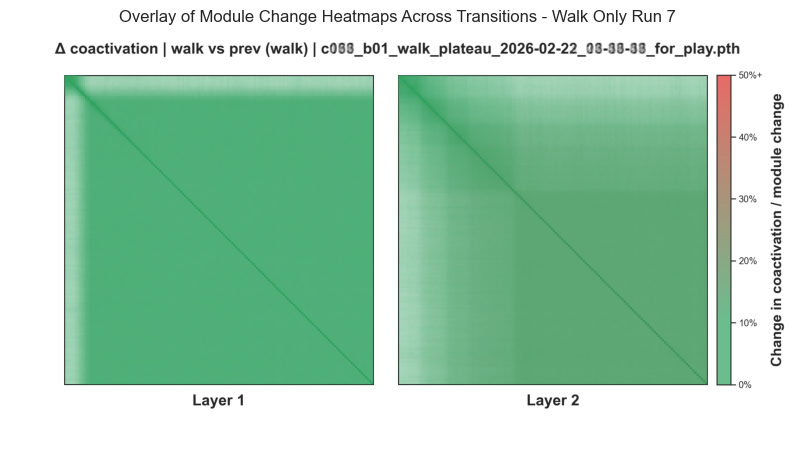

In [5]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import os, glob

folder_path = "/Users/adi/Desktop/EmergentRobotSelf/Checkpoints_States_selectedGraphs/Walk_robustness/WSJ_att69_WalkOnly_relu_7_2026-02-21_01-38-49/models/transiton_plots/PlotB"
pattern = "*.png"  # e.g. "*_Original.png" or "*.png"

image_paths = sorted(glob.glob(os.path.join(folder_path, pattern)))
if len(image_paths) == 0:
    raise FileNotFoundError(f"No files matched pattern '{pattern}' in: {folder_path}")

print(f"Found {len(image_paths)} images.")

base_img = Image.open(image_paths[0]).convert("RGB")
width, height = base_img.size

images = []
for path in image_paths:
    img = Image.open(path).convert("RGB")
    if img.size != (width, height):
        img = img.resize((width, height), resample=Image.BILINEAR)
    images.append(np.array(img).astype(np.float32))

stack = np.stack(images, axis=0)
avg_img = np.mean(stack, axis=0)
avg_img = np.clip(avg_img, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 10))
plt.imshow(avg_img)
plt.axis("off")
plt.title("Overlay of Module Change Heatmaps Across Transitions - Walk Only Run 7")
plt.show()